# Davidson Rafael - 41204030
## Praktikum Pengolahan Citra Digital: Sub-CPMK 4
## Perbaikan Tampilan Citra dengan Transformasi Intensitas dan Histogram

Setelah praktikum ini, mahasiswa dapat mengenali masalah kecerahan atau kontras, mencoba gamma, histogram equalization, dan CLAHE, lalu memilih hasil berdasarkan bagian gambar yang ingin diperjelas.

**Pola kerja:** prediksi, jalankan, amati, lalu jelaskan.

## Aturan latihan

Latihan wajib mengulang langkah yang sudah didemonstrasikan. Mahasiswa hanya mengubah parameter yang ditandai. Penggunaan foto lain tersedia setelah latihan wajib selesai.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11
print("OpenCV:", cv2.__version__)

OpenCV: 5.0.0


In [2]:
ASSET_DIR = Path("assets/subcpmk4")

def gamma_correction(image, gamma):
    normalized = image.astype(np.float32) / 255.0
    result = 255 * np.power(normalized, gamma)
    return np.clip(result, 0, 255).astype(np.uint8)

def pencahayaan_tidak_merata(image, kiri=0.30, kanan=1.08):
    h, w = image.shape
    gradient = np.tile(np.linspace(kiri, kanan, w, dtype=np.float32), (h, 1))
    return np.clip(image.astype(np.float32) * gradient, 0, 255).astype(np.uint8)

demo_path = ASSET_DIR / "demo_cahaya_tidak_merata.png"
latihan_path = ASSET_DIR / "latihan_cahaya_tidak_merata.png"

if demo_path.exists() and latihan_path.exists():
    demo = cv2.imread(str(demo_path), cv2.IMREAD_GRAYSCALE)
    latihan = cv2.imread(str(latihan_path), cv2.IMREAD_GRAYSCALE)
else:
    demo = pencahayaan_tidak_merata(data.camera().astype(np.uint8))
    latihan = pencahayaan_tidak_merata(data.coins().astype(np.uint8), 0.35, 1.05)

print("Demo:", demo.shape, demo.dtype)
print("Latihan:", latihan.shape, latihan.dtype)

Demo: (512, 512) uint8
Latihan: (303, 384) uint8


In [3]:
def tampilkan(image, judul="Citra", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(judul)
    ax.axis("off")

def tampilkan_dengan_histogram(image, judul="Citra"):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
    tampilkan(image, judul, ax[0])
    ax[1].hist(image.ravel(), 256, [0, 256], color="#153A70")
    ax[1].set_title("Histogram")
    ax[1].set_xlim(0, 255)
    ax[1].set_xlabel("Intensitas")
    ax[1].set_ylabel("Jumlah piksel")
    plt.tight_layout()
    plt.show()

def bandingkan(images, titles, figsize=(15, 4)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    for ax, image, title in zip(axes, images, titles):
        tampilkan(image, title, ax)
    plt.tight_layout()
    plt.show()

## 1. Diagnosis citra sebelum pengolahan

Perhatikan gambar dan histogram. Tentukan wilayah yang ingin diperjelas. Histogram menunjukkan distribusi intensitas, tetapi tidak menunjukkan posisi piksel.

/var/folders/mt/3hrd1lmd6nb6fwvw2g71tb500000gn/T/ipykernel_97584/3651747186.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1].hist(image.ravel(), 256, [0, 256], color="#153A70")


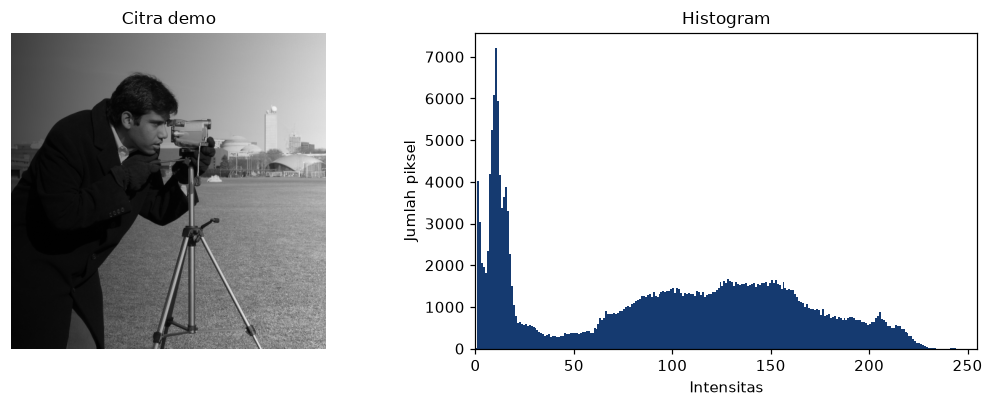

In [4]:
tampilkan_dengan_histogram(demo, "Citra demo")

**Prediksi sebelum lanjut:** jika semua piksel dibuat lebih terang, apa yang mungkin terjadi pada bagian yang sudah terang?

Jawaban yang diharapkan: nilai dapat mencapai 255 dan kehilangan perbedaan karena clipping.

In [5]:
contoh = np.array([230, 250], dtype=np.int16)
setelah_tambah = np.clip(contoh + 40, 0, 255)
setelah_digelapkan = np.clip(setelah_tambah - 40, 0, 255)
print("Awal             :", contoh)
print("Tambah 40        :", setelah_tambah)
print("Kemudian kurangi :", setelah_digelapkan)

Awal             : [230 250]
Tambah 40        : [255 255]
Kemudian kurangi : [215 215]


## 2. Transformasi intensitas singkat

Setiap piksel input `r` dipetakan menjadi output `s`. Negatif membalik terang dan gelap. Transformasi log menonjolkan perbedaan pada intensitas rendah. Keduanya menjadi pengantar sebelum eksperimen gamma.

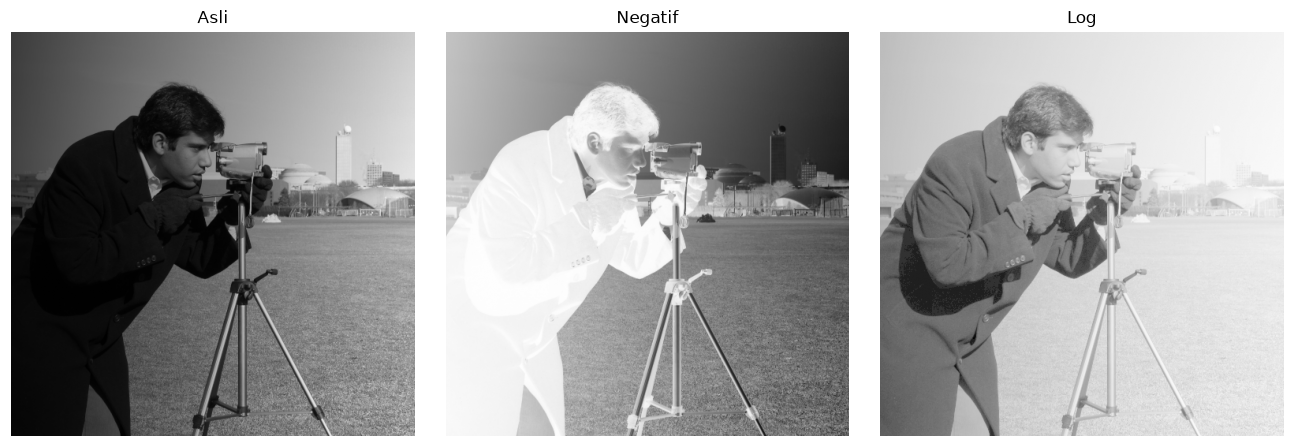

In [6]:
negatif = 255 - demo
c = 255 / np.log1p(255)
log_result = np.clip(c * np.log1p(demo.astype(np.float32)), 0, 255).astype(np.uint8)
bandingkan([demo, negatif, log_result], ["Asli", "Negatif", "Log"], figsize=(12, 4))

## 3. Gamma correction

Notebook ini memakai rumus `s = 255 × (r/255)^gamma`. Gamma di bawah 1 mencerahkan nilai tengah, gamma 1 mempertahankan citra, dan gamma di atas 1 menggelapkan.

**Prediksi dahulu:** dari gamma 0,5; 1; dan 2, mana yang paling mungkin memperjelas citra gelap?

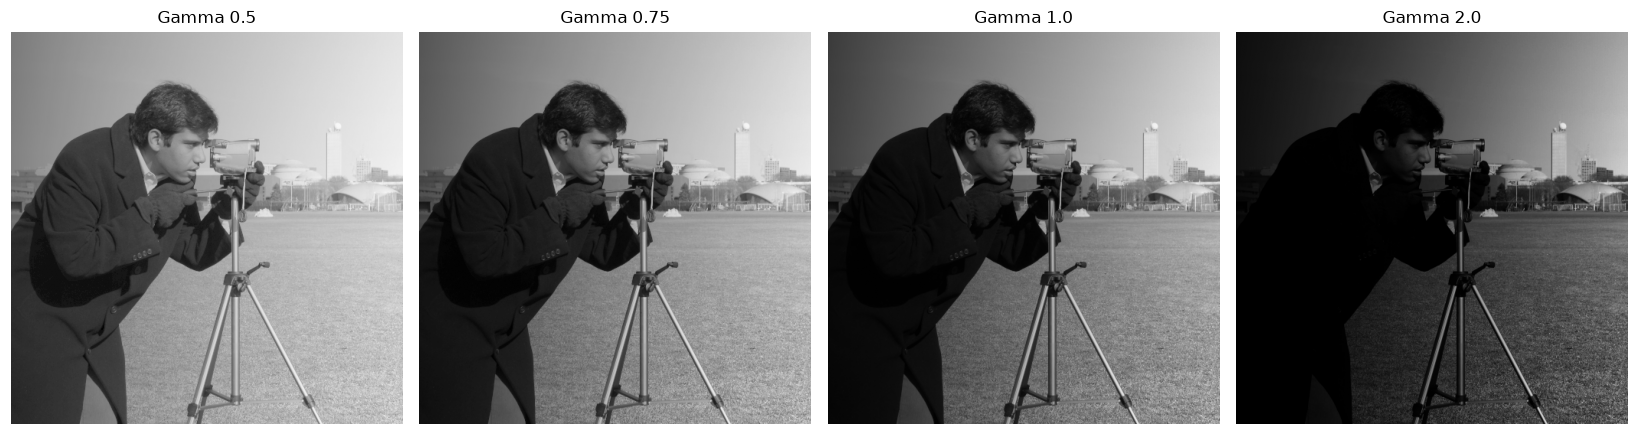

In [7]:
gamma_values = [0.5, 0.75, 1.0, 2.0]
gamma_images = [gamma_correction(demo, g) for g in gamma_values]
bandingkan(gamma_images, [f"Gamma {g}" for g in gamma_values], figsize=(15, 4))

**Jawaban prediksi:** gamma 0,5 yang paling mungkin memperjelas citra gelap.

Setelah dijalankan memang gamma 0,5 dan 0,75 bikin bagian gelap di sisi kiri jadi lebih kebaca, sedangkan gamma 1,0 sama persis kayak aslinya karena `r/255` dipangkatin 1. Gamma 2,0 malah bikin sisi kiri makin gelap sampai hampir rata hitam, jadi detailnya ilang.


## 4. Histogram equalization global

Equalization global membentuk pemetaan dari histogram kumulatif seluruh citra. Metode ini dapat memperlebar rentang intensitas, tetapi satu pemetaan berlaku untuk seluruh lokasi.

/var/folders/mt/3hrd1lmd6nb6fwvw2g71tb500000gn/T/ipykernel_97584/3651747186.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1].hist(image.ravel(), 256, [0, 256], color="#153A70")


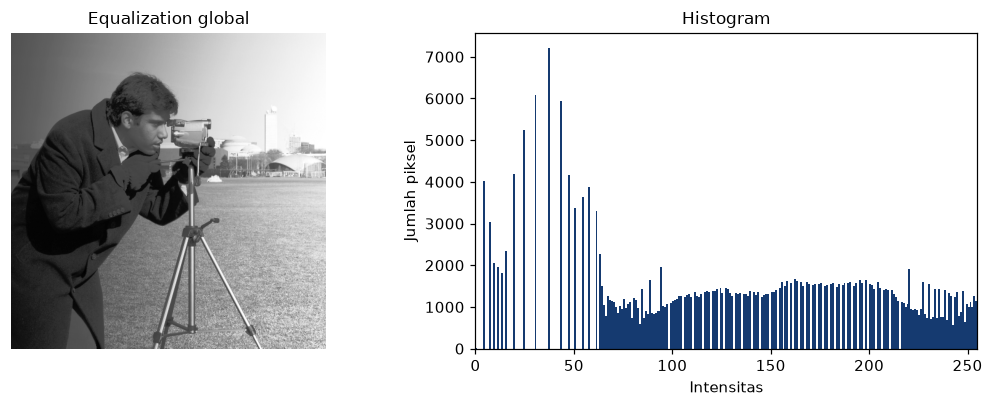

In [8]:
equalized_demo = cv2.equalizeHist(demo)
tampilkan_dengan_histogram(equalized_demo, "Equalization global")

## 5. CLAHE

CLAHE bekerja pada pembagian wilayah citra dan membatasi penguatan kontras. `tileGridSize=(8, 8)` berarti citra dibagi menjadi delapan bagian pada setiap arah. Pada latihan utama, grid tetap dan hanya `clipLimit` yang diubah.

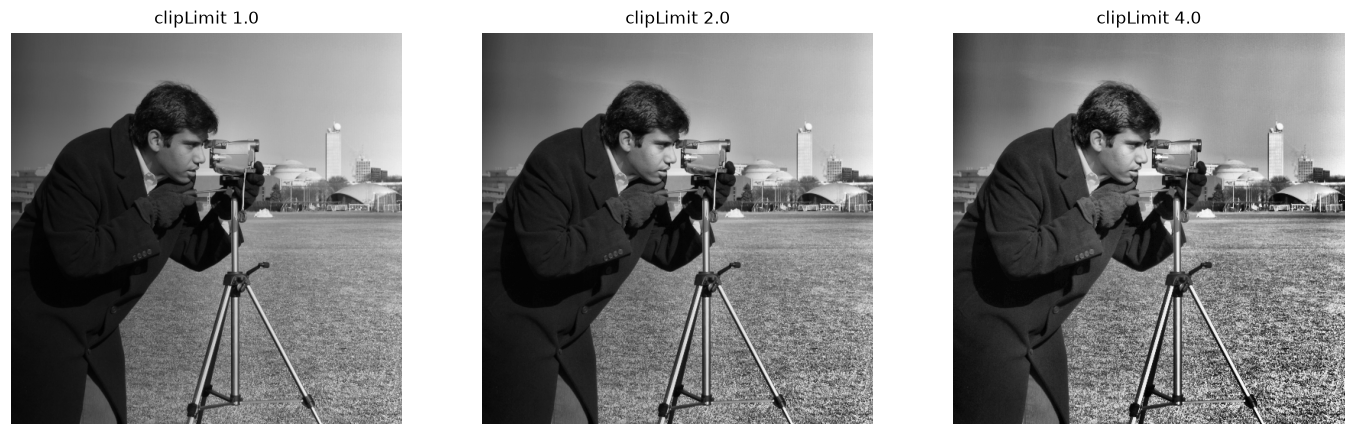

In [9]:
clahe_results = []
clip_values = [1.0, 2.0, 4.0]
for clip in clip_values:
    operator = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    clahe_results.append(operator.apply(demo))
bandingkan(clahe_results, [f"clipLimit {v}" for v in clip_values], figsize=(13, 4))

## 6. Perbandingan metode

Semua hasil berikut berasal dari citra input yang sama. Periksa area gelap, detail di area terang, dan derau yang ikut terlihat.

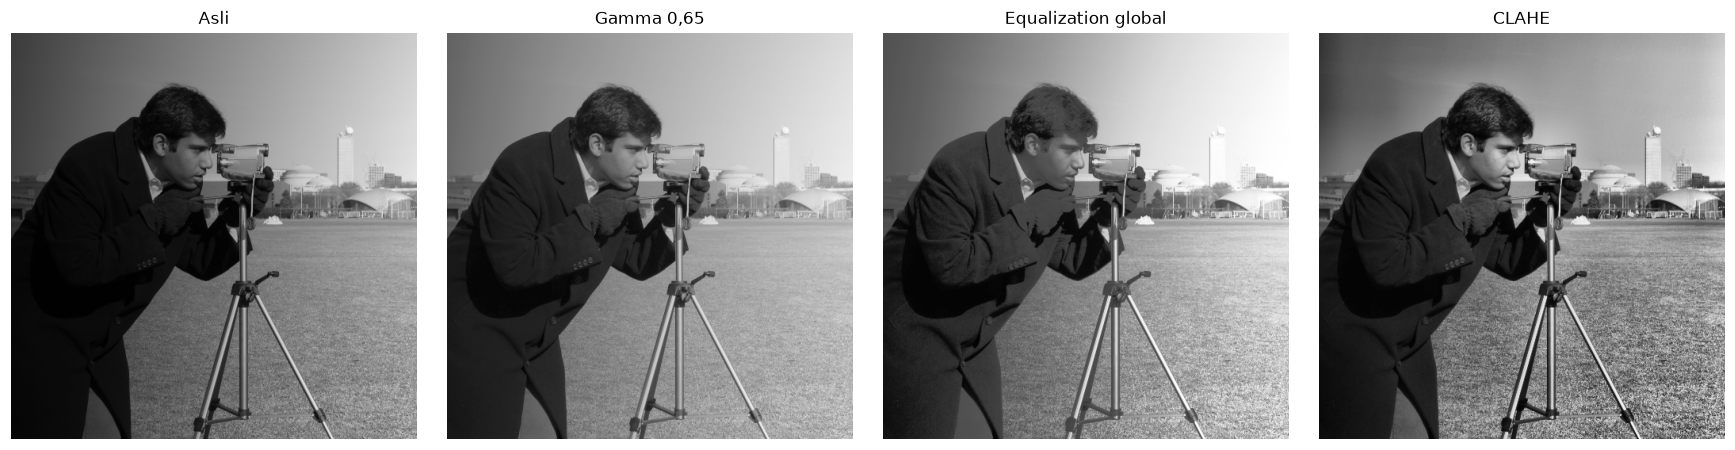

In [10]:
# Tiga metode yang akan dibandingkan. Semua dihitung dari citra demo yang sama.
hasil_gamma = gamma_correction(demo, gamma=0.65)
hasil_equalization = cv2.equalizeHist(demo)

objek_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
hasil_clahe = objek_clahe.apply(demo)

bandingkan(
    [demo, hasil_gamma, hasil_equalization, hasil_clahe],
    ["Asli", "Gamma 0,65", "Equalization global", "CLAHE"],
    figsize=(16, 4)
)

## 7. Latihan wajib: ulangi demonstrasi

Gunakan citra `latihan`. Urutan dan kode sama dengan demonstrasi. Mahasiswa hanya memilih gamma dan `clipLimit` dari nilai yang tersedia.

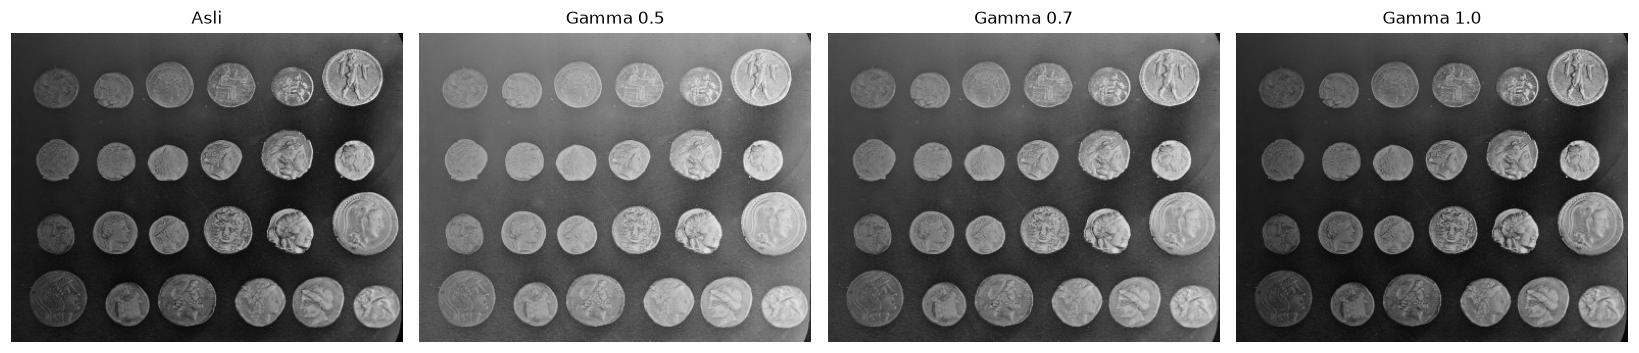

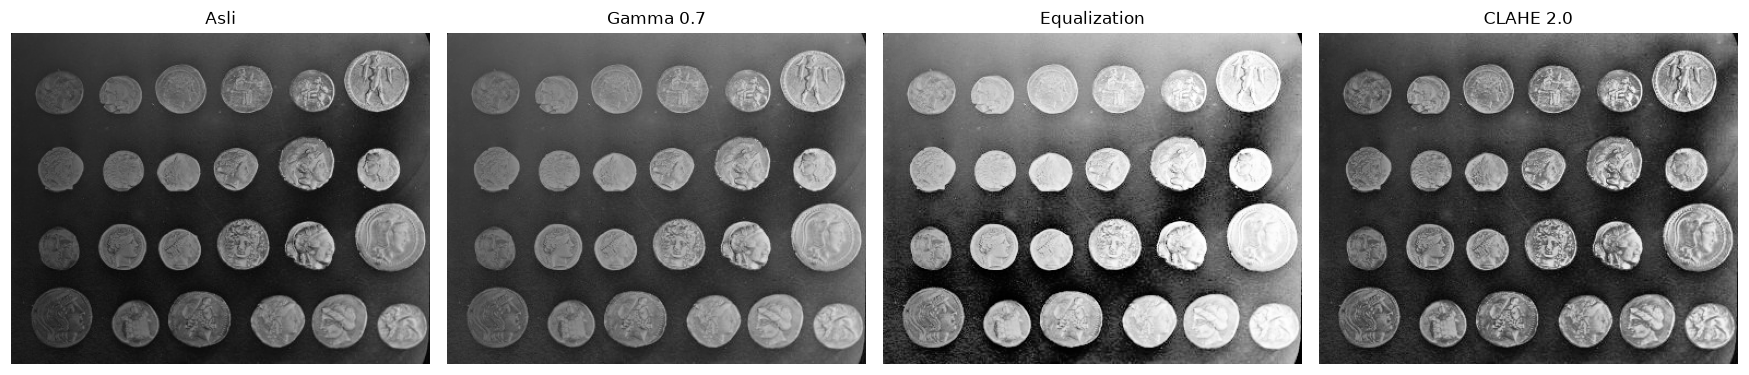

In [11]:
# LATIHAN WAJIB
# Ikuti langkah yang sama seperti demonstrasi. Ubah hanya nilai yang ditandai.

# 1. Coba tiga gamma yang sudah disediakan.
gamma_dicoba = [0.50, 0.70, 1.00]
hasil_gamma_latihan = [gamma_correction(latihan, g) for g in gamma_dicoba]
bandingkan(
    [latihan] + hasil_gamma_latihan,
    ["Asli"] + [f"Gamma {g}" for g in gamma_dicoba],
    figsize=(15, 4)
)

# 2. Pilih satu gamma dari daftar di atas.
# Pilihan saya: 0.70. Gamma 0.50 udah kelewat terang jadi koin sama background nyatu,
# gamma 1.00 gak ngubah apa-apa.
gamma_pilihan = 0.70
hasil_gamma_pilihan = gamma_correction(latihan, gamma_pilihan)

# 3. Ulangi equalization global dan CLAHE seperti pada demonstrasi.
hasil_equalization_latihan = cv2.equalizeHist(latihan)

# Sudah dicoba clipLimit 1.0 dan 2.0 (lihat sel di bawah), yang dipilih 2.0.
clip_pilihan = 2.0
clahe_latihan = cv2.createCLAHE(clipLimit=clip_pilihan, tileGridSize=(8, 8))
hasil_clahe_latihan = clahe_latihan.apply(latihan)

# 4. Bandingkan seluruh hasil dari input yang sama.
bandingkan(
    [latihan, hasil_gamma_pilihan, hasil_equalization_latihan, hasil_clahe_latihan],
    ["Asli", f"Gamma {gamma_pilihan}", "Equalization", f"CLAHE {clip_pilihan}"],
    figsize=(16, 4)
)


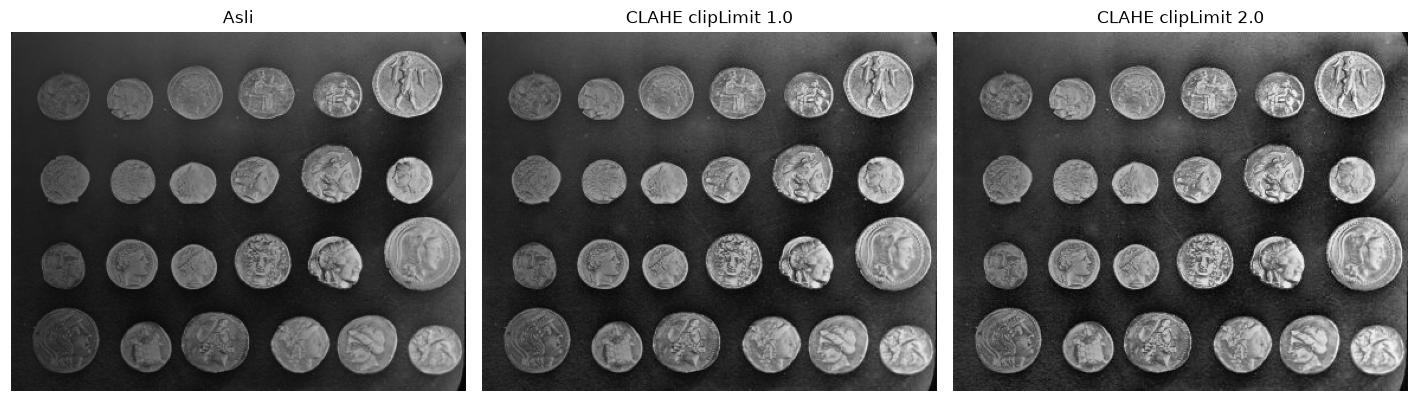

Asli                   mean=  66.4  std= 42.7  piksel>=250= 0.00%  piksel<=10= 0.16%
Gamma 0.5              mean= 123.3  std= 40.1  piksel>=250= 0.00%  piksel<=10= 0.00%
Gamma 0.7              mean=  95.0  std= 43.2  piksel>=250= 0.00%  piksel<=10= 0.00%
Gamma 1.0              mean=  66.4  std= 42.7  piksel>=250= 0.00%  piksel<=10= 0.16%
Equalization global    mean= 128.8  std= 72.9  piksel>=250= 2.26%  piksel<=10= 3.68%
CLAHE clipLimit 1.0    mean=  77.2  std= 49.8  piksel>=250= 0.00%  piksel<=10= 0.20%
CLAHE clipLimit 2.0    mean=  85.3  std= 54.0  piksel>=250= 0.00%  piksel<=10= 0.40%


In [12]:
# Perbandingan dua clipLimit yang diminta, dari citra latihan yang sama.
clip_dicoba = [1.0, 2.0]
hasil_clip = [
    cv2.createCLAHE(clipLimit=c, tileGridSize=(8, 8)).apply(latihan)
    for c in clip_dicoba
]
bandingkan(
    [latihan] + hasil_clip,
    ["Asli"] + [f"CLAHE clipLimit {c}" for c in clip_dicoba],
    figsize=(13, 4)
)

# Angka pendukung buat ngisi tabel pengamatan.
def ringkasan(nama, citra):
    persen_putih = (citra >= 250).mean() * 100
    persen_hitam = (citra <= 10).mean() * 100
    print(
        f"{nama:22s} mean={citra.mean():6.1f}  std={citra.std():5.1f}  "
        f"piksel>=250={persen_putih:5.2f}%  piksel<=10={persen_hitam:5.2f}%"
    )

ringkasan("Asli", latihan)
for g, hasil in zip(gamma_dicoba, hasil_gamma_latihan):
    ringkasan(f"Gamma {g}", hasil)
ringkasan("Equalization global", hasil_equalization_latihan)
for c, hasil in zip(clip_dicoba, hasil_clip):
    ringkasan(f"CLAHE clipLimit {c}", hasil)


### Catatan hasil

Citra latihan adalah foto koin yang dikasih pencahayaan gak merata, sisi kiri gelap dan sisi kanan lebih terang (mean awal 66,4 dengan std 42,7).

| Metode | Parameter | Detail yang lebih terlihat | Efek yang kurang diinginkan |
|---|---|---|---|
| Gamma | 0,70 | koin di sisi kiri yang tadinya nyaris nyatu sama background jadi kebaca, mean naik dari 66,4 ke 95,0 | beda terang kiri-kanan tetep kebawa, jadi cuma digeser terangnya bukan diratain |
| Equalization global | tidak ada | sebaran intensitas paling lebar, std naik dari 42,7 ke 72,9 dan koin sisi kanan paling menonjol | sekitar 2,3% piksel mentok di 255 jadi ukiran koin sisi kanan ke-clip, noise background ikut keangkat |
| CLAHE | clipLimit 2,0 dan tileGridSize (8, 8) | relief/ukiran koin di sisi kiri maupun kanan sama-sama kebaca, std naik dari 42,7 ke 54,0 tanpa ada piksel yang mentok 255 | tekstur halus di background ikut naik dikit, makin kelihatan kalau clipLimit dinaikin ke 4,0 |

**Pilihan hasil:** CLAHE dengan clipLimit 2,0 dan tileGridSize (8, 8).

**Alasan:** bagian yang mau saya perjelas itu ukiran di permukaan koin, terutama koin baris kiri yang kena bagian paling gelap. Di hasil CLAHE koin kiri sama kanan sama-sama kebaca ukirannya karena kontras dihitung per tile, jadi pencahayaan yang gak merata gak dibawa ke satu pemetaan global. Equalization global sebenernya paling lebar sebarannya, tapi koin di sisi kanan malah jadi putih kepotong di 255 (2,3% piksel) hingga detailnya hilang. Gamma 0,70 cuma mencerahkan tanpa benerin beda terang kiri-kanan, jadi koin sisi kiri masih kalah kontras dari yang kanan.


## 8. Tambahan opsional

Bagian ini dikerjakan setelah latihan wajib selesai. Mahasiswa dapat memakai gambar lain atau foto sendiri, lalu mengulang blok perbandingan yang sama.

/var/folders/mt/3hrd1lmd6nb6fwvw2g71tb500000gn/T/ipykernel_97584/3651747186.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1].hist(image.ravel(), 256, [0, 256], color="#153A70")


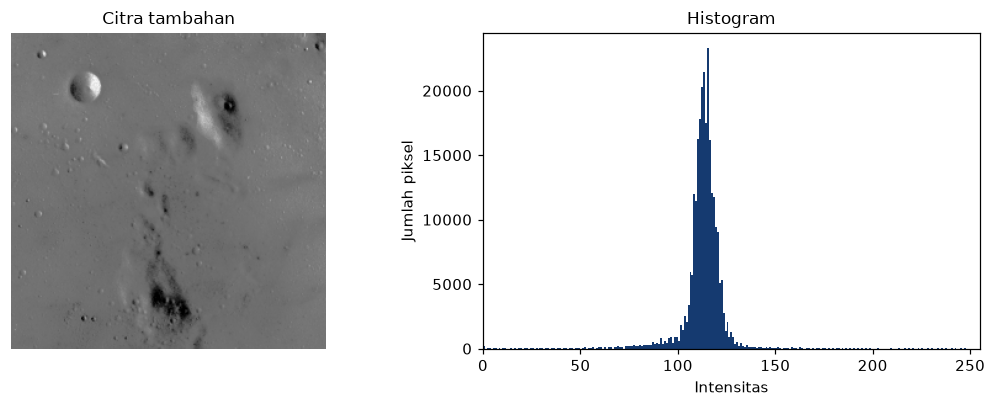

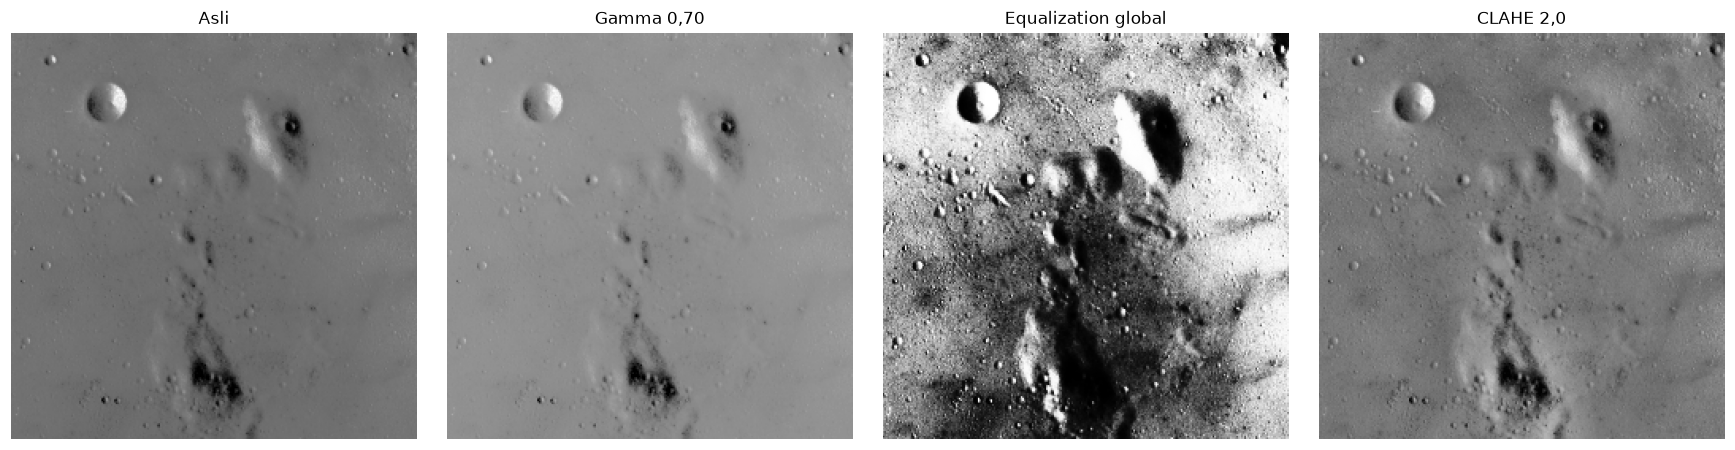

Asli                   mean= 112.2  std= 13.3  piksel>=250= 0.00%  piksel<=10= 0.21%
Gamma 0.7              mean= 142.8  std= 13.1  piksel>=250= 0.00%  piksel<=10= 0.11%
Equalization global    mean= 133.8  std= 74.0  piksel>=250= 2.36%  piksel<=10= 4.17%
CLAHE clipLimit 2.0    mean= 119.9  std= 18.5  piksel>=250= 0.00%  piksel<=10= 0.20%


In [13]:
# OPSIONAL SETELAH LATIHAN WAJIB SELESAI
# Kalau ada foto sendiri, aktifkan blok upload Colab di bawah.
# Kalau gak ada, dipakai citra bulan dari skimage yang kontrasnya emang rendah.

# from google.colab import files
# uploaded = files.upload()
# nama_file = next(iter(uploaded))
# foto = cv2.imread(nama_file, cv2.IMREAD_GRAYSCALE)

foto = data.moon().astype(np.uint8)
tampilkan_dengan_histogram(foto, "Citra tambahan")

# Ulangi blok perbandingan yang sama seperti latihan wajib.
foto_gamma = gamma_correction(foto, 0.70)
foto_equalization = cv2.equalizeHist(foto)
foto_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(foto)

bandingkan(
    [foto, foto_gamma, foto_equalization, foto_clahe],
    ["Asli", "Gamma 0,70", "Equalization global", "CLAHE 2,0"],
    figsize=(16, 4)
)

ringkasan("Asli", foto)
ringkasan("Gamma 0.7", foto_gamma)
ringkasan("Equalization global", foto_equalization)
ringkasan("CLAHE clipLimit 2.0", foto_clahe)


Citra tambahan ini masalahnya beda sama citra latihan: cahayanya rata tapi kontrasnya rendah di seluruh bagian, histogramnya numpuk di rentang sempit sekitar nilai 112 dengan std cuma 13,3, jadi permukaannya kelihatan berkabut.

Karena masalahnya global, di sini equalization global justru yang paling ngangkat detail, std naik dari 13,3 ke 74,0 dan kawah sama jejak di permukaan jadi jelas banget, walaupun ada 2,36% piksel yang mentok di 255 dan butiran noise ikut kelihatan. CLAHE clipLimit 2,0 cuma naikin std ke 18,5 jadi perubahannya tipis, sedangkan gamma 0,70 cuma bikin lebih terang tanpa nambah kontras (std tetep 13,1). Jadi metode terbaik ngikutin jenis masalahnya: CLAHE menang pas cahayanya gak merata, equalization global menang pas kontras rendahnya rata di seluruh citra.


## Pengumpulan

Kumpulkan notebook yang sudah dijalankan. Pastikan perbandingan empat gambar, tabel pengamatan, pilihan hasil, dan alasannya sudah terlihat.